In [ ]:
#Load data and set up

import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA = Path("../data")

# Load preprocessed arrays from §6 of preprocessing.ipynb
X_train = np.load(DATA / "X_cls_train.npy")
X_val   = np.load(DATA / "X_cls_val.npy")
X_test  = np.load(DATA / "X_cls_test.npy")
y_train = np.load(DATA / "y_cls_train.npy")
y_val   = np.load(DATA / "y_cls_val.npy")
y_test  = np.load(DATA / "y_cls_test.npy")
class_weights = np.load(DATA / "class_weights.npy")


# ANN-specific softening: full "balanced" weights (8.35x for Inadequate) proved
# too aggressive in the first training run — the model over-predicted minority
# classes and collapsed Good recall. Square-root softening preserves the
# minority-class boost but at a gentler ratio.
class_weights_soft = np.sqrt(class_weights)
class_weights_t = torch.FloatTensor(class_weights_soft)
print(f"Original balanced weights: {class_weights.round(2)}")
print(f"Softened (sqrt) weights:   {class_weights_soft.round(2)}")

grade_labels = ["Inadequate", "Requires improvement", "Good", "Outstanding"]

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_val_t   = torch.FloatTensor(X_val)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_val_t   = torch.LongTensor(y_val)
y_test_t  = torch.LongTensor(y_test)
class_weights_t = torch.FloatTensor(class_weights)

print(f"Train: {X_train_t.shape} | Val: {X_val_t.shape} | Test: {X_test_t.shape}")
print(f"Class weights: {class_weights.round(2)}")

Train: torch.Size([1269, 16]) | Val: torch.Size([272, 16]) | Test: torch.Size([273, 16])
Class weights: [8.35 1.8  0.37 1.67]


In [2]:
#Create ANN architecture

class OfstedANN(nn.Module):
    """
    Feed-forward ANN for 4-class Ofsted grade classification.
    Architecture: 16 -> 32 -> 16 -> 4 with ReLU activations and dropout regularisation.
    """
    def __init__(self, n_features=16, n_classes=4, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, n_classes),
        )

    def forward(self, x):
        return self.net(x)

model = OfstedANN(n_features=16, n_classes=4, dropout=0.3)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")

OfstedANN(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=4, bias=True)
  )
)

Total trainable parameters: 1,140


In [ ]:
#Train the model

# Hyperparameters
EPOCHS       = 200
LR           = 0.001
PATIENCE     = 20   # early stopping if val macro-F1 doesn't improve for 20 epochs

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses, val_macrof1s = [], [], []
best_val_macrof1 = -1
best_epoch = 0
best_state = None
epochs_no_improve = 0

for epoch in range(EPOCHS):
    # ── Train ─────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # ── Evaluate on validation ────────────────────
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_preds = val_logits.argmax(dim=1).numpy()
        val_macrof1 = f1_score(y_val, val_preds, average="macro")

    val_losses.append(val_loss)
    val_macrof1s.append(val_macrof1)

    # ── Early stopping check ──────────────────────
    if val_macrof1 > best_val_macrof1:
        best_val_macrof1 = val_macrof1
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:>3}: train_loss={loss.item():.4f}  val_loss={val_loss:.4f}  val_macroF1={val_macrof1:.3f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.")
        break

# Restore best model
model.load_state_dict(best_state)
print(f"\nBest model: epoch {best_epoch}, val macro-F1 = {best_val_macrof1:.3f}")

Epoch   0: train_loss=1.4068  val_loss=1.4119  val_macroF1=0.060
Epoch  10: train_loss=1.3691  val_loss=1.3664  val_macroF1=0.072
Epoch  20: train_loss=1.3385  val_loss=1.3247  val_macroF1=0.176
Epoch  30: train_loss=1.2973  val_loss=1.2825  val_macroF1=0.199
Epoch  40: train_loss=1.2753  val_loss=1.2400  val_macroF1=0.210
Epoch  50: train_loss=1.2319  val_loss=1.1989  val_macroF1=0.208
Epoch  60: train_loss=1.1849  val_loss=1.1646  val_macroF1=0.256
Epoch  70: train_loss=1.1550  val_loss=1.1375  val_macroF1=0.254
Epoch  80: train_loss=1.1516  val_loss=1.1192  val_macroF1=0.281
Epoch  90: train_loss=1.1324  val_loss=1.1071  val_macroF1=0.296
Epoch 100: train_loss=1.1313  val_loss=1.0977  val_macroF1=0.320
Epoch 110: train_loss=1.0871  val_loss=1.0901  val_macroF1=0.316

Early stopping at epoch 118 — no improvement for 20 epochs.

Best model: epoch 98, val macro-F1 = 0.325


In [4]:
#Evaluate on test set

model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_preds = test_logits.argmax(dim=1).numpy()

test_macrof1 = f1_score(y_test, test_preds, average="macro")
test_accuracy = accuracy_score(y_test, test_preds)

print(f"═══ ANN Test-set performance ═══")
print(f"Macro-F1:  {test_macrof1:.3f}")
print(f"Accuracy:  {test_accuracy:.3f}")
print()
print(classification_report(y_test, test_preds, target_names=grade_labels))
print("Confusion matrix (rows=true, cols=predicted):")
cm = confusion_matrix(y_test, test_preds)
print(pd.DataFrame(cm, index=grade_labels, columns=grade_labels))

# Save best model weights
import os
os.makedirs("../models", exist_ok=True)
torch.save(best_state, "../models/ofsted_ann.pt")
print("\nSaved best model to ../models/ofsted_ann.pt")

═══ ANN Test-set performance ═══
Macro-F1:  0.285
Accuracy:  0.333

                      precision    recall  f1-score   support

          Inadequate       0.00      0.00      0.00         8
Requires improvement       0.23      0.74      0.35        38
                Good       0.85      0.12      0.22       186
         Outstanding       0.40      0.98      0.57        41

            accuracy                           0.33       273
           macro avg       0.37      0.46      0.28       273
        weighted avg       0.67      0.33      0.28       273

Confusion matrix (rows=true, cols=predicted):
                      Inadequate  Requires improvement  Good  Outstanding
Inadequate                     0                     7     1            0
Requires improvement           6                    28     3            1
Good                          19                    86    23           58
Outstanding                    1                     0     0           40

Saved best model

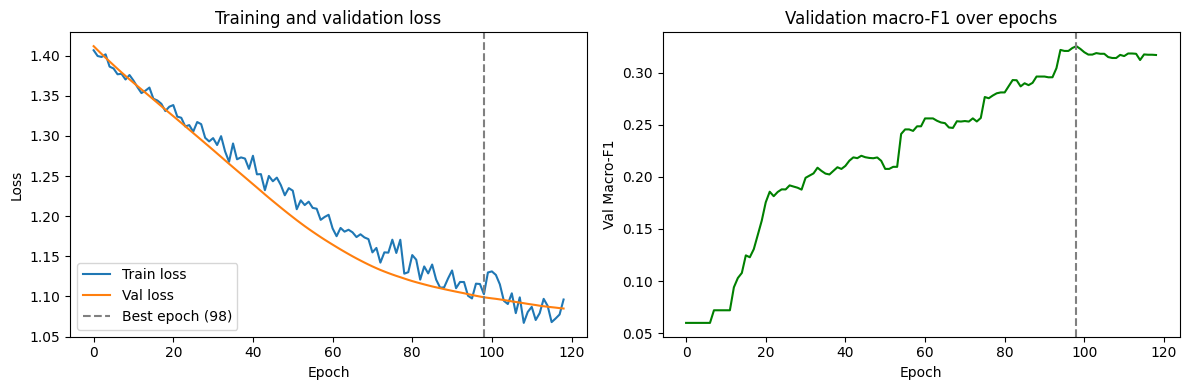


Model comparison:
                    Model  Macro-F1  Accuracy
Logistic Regression (val)     0.380     0.430
      Random Forest (val)     0.460     0.620
               ANN (test)     0.285     0.333


In [5]:
#Comparison with baselines

import matplotlib.pyplot as plt

# ── Training curves ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train loss")
axes[0].plot(val_losses, label="Val loss")
axes[0].axvline(best_epoch, color="grey", linestyle="--", label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and validation loss")
axes[0].legend()

axes[1].plot(val_macrof1s, color="green")
axes[1].axvline(best_epoch, color="grey", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Macro-F1")
axes[1].set_title("Validation macro-F1 over epochs")
plt.tight_layout()
plt.savefig("../SRC/EDA/fig_ann_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Comparison table ───────────────────────────────
# Test-set metrics — you'll need LR and RF test-set predictions.
# For now, report from validation set (baselines were evaluated on val).
# TODO: also evaluate LR and RF on test set for apples-to-apples comparison.
comparison = pd.DataFrame({
    "Model":         ["Logistic Regression (val)", "Random Forest (val)", "ANN (test)"],
    "Macro-F1":      [0.38, 0.46, round(test_macrof1, 3)],
    "Accuracy":      [0.43, 0.62, round(test_accuracy, 3)],
})
print("\nModel comparison:")
print(comparison.to_string(index=False))